# ***Assignment 2***

#### **Name:**  *Ishitha Konda*
Student ID: 11592291

# ***Task 1: Data preparation***

#### You are provided three files, i.e., text files containing bus logs of 3 different scenarios


#### *   CAN Bus log - injection of FFF as the speed reading
#### *   CAN Bus log - injection of RPM readings
#### *   CAN bus log - no injection of messages




#### Update your Python module to read the datasets were provided in assignment 1.

In [ ]:
!pip install hmmlearn

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
# importing modules
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
from sklearn.metrics import accuracy_score

In [ ]:
#processing the data
def getData(filename):

  f = open(filename) #opening the file
  read_file =f.readlines()
  
  speed = [] #List to store speed
  rpm = [] #List to store rpm

  i = 0

  for row in read_file:

    #record to store the values of data from vehicle
    record = {'stamp':row[1:18], 'PID':row[25:28], 'const1':row[29:33], 'change':row[33:41],'value':int(row[41:45], 16), 'value2':0 ,'attack':0}
    
    if record["PID"] == '254': #Processing of speed
      if record["value"] >= 4095:
        record["attack"] = 1
      record['value'] =  (record['value'] * 0.62137119) /100
      speed.append(record)
    
    if record["PID"] == '115': #Processing of RPM 
      if record["value"] >= 65535:
        record["attack"] = 1
      record['value'] =  (record['value'] * 2)
      rpm.append(record)
    i = i+1   
    record={}
    
  f.close()
  
  #returning the lists
  return pd.DataFrame(speed),pd.DataFrame(rpm)

In [ ]:
# speed1 is the data frame for speeds from CAN bus log - no injection of messages.log
# rpm1 is the data frame for rpm from CAN bus log - no injection of messages.log
speed1,rpm1 = getData("/content/CAN bus log - no injection of messages.log")


In [ ]:
# speed2 is the data frame for speeds from CAN Bus log - injection of RPM readings.log
# rpm2 is the data frame for rpm from CAN Bus log - injection of RPM readings.log
speed2,rpm2 = getData("/content/CAN Bus log - injection of RPM readings.log")

In [ ]:
# speed3 is the data frame for speeds from CAN bus log - injection of FFF as the speed reading.log
# rpm3 is the data frame for rpm from CAN bus log - injection of FFF as the speed reading.log
speed3,rpm3 = getData("/content/CAN Bus log - injection of FFF as the speed reading.log")

In [ ]:
# Getting values from dataframe
original_speed1 = list(speed1["value"])
original_speed2 = list(speed2["value"])
original_speed3 = list(speed3["value"])
original_rpm1 = list(rpm1["value"])
original_rpm2 = list(rpm2["value"])
original_rpm3 = list(rpm3["value"])

In [ ]:
# dropping columns
speed1 = speed1.drop(['PID', 'const1', 'change', 'value2','attack'], axis = 1)
rpm1 = rpm1.drop(['PID', 'const1', 'change', 'value2','attack'], axis = 1)
speed2 = speed2.drop(['PID', 'const1', 'change', 'value2','attack'], axis = 1)
rpm2 = rpm2.drop(['PID', 'const1', 'change', 'value2','attack'], axis = 1)
speed3 = speed3.drop(['PID', 'const1', 'change', 'value2','attack'], axis = 1)
rpm3 = rpm3.drop(['PID', 'const1', 'change', 'value2','attack'], axis = 1)


In [ ]:
# Adding column with the values
speed1['SpeedValue'] = original_speed1
speed2['SpeedValue'] = original_speed2
speed3['SpeedValue'] = original_speed3
rpm1['RPMValue'] = original_rpm1
rpm2['RPMValue'] = original_rpm2
rpm3['RPMValue'] = original_rpm3

In [ ]:
scaler = StandardScaler()
speed1[['stamp', 'value']] = scaler.fit_transform(speed1[['stamp', 'value']])
rpm1[['stamp', 'value']] = scaler.fit_transform(rpm1[['stamp', 'value']])
speed2[['stamp', 'value']] = scaler.fit_transform(speed2[['stamp', 'value']])
rpm2[['stamp', 'value']] = scaler.fit_transform(rpm2[['stamp', 'value']])
speed3[['stamp', 'value']] = scaler.fit_transform(speed3[['stamp', 'value']])
rpm3[['stamp', 'value']] = scaler.fit_transform(rpm3[['stamp', 'value']])

# ***Task 2 - k-mean Clustering***

#### K-means clustering is one of the simplest and most popular unsupervised machine learning algorithms. A cluster refers to a collection of data points aggregated together because of certain similarities. You’ll define a target number k, which refers to the number of centroids you need in the dataset. A centroid is the imaginary or real location representing the center of the cluster. For this assignment you need to set k = 2 as we have 2 outcomes (i.e., Attack = 0 and Attack = 1)

#### You need to fit k-mean clustering separately for 6 datasets (1 Speed and 1 RPM dataframe for each of 3 scenarios).
#### 1. Use scatter plot to show the fitted k-mean clusters.  
#### 2. Provide the centroids of each clusters.
#### 3. Compare and discuss the scatter plots of the three scenarios from the speed datasets. Do the same for the RPM datasets.





In [ ]:
# Creating the KMeans model 
kmeans_s1 = KMeans(n_clusters=2)
kmeans_s2 = KMeans(n_clusters=2)
kmeans_s3 = KMeans(n_clusters=2)
kmeans_r1 = KMeans(n_clusters=2)
kmeans_r2 = KMeans(n_clusters=2)
kmeans_r3 = KMeans(n_clusters=2)

In [ ]:
# Fit the model to our dataset
kmeans_s1.fit(speed1[['stamp','value']])
kmeans_s2.fit(speed2[['stamp','value']])
kmeans_s3.fit(speed3[['stamp','value']])
kmeans_r1.fit(rpm1[['stamp','value']])
kmeans_r2.fit(rpm2[['stamp','value']])
kmeans_r3.fit(rpm3[['stamp','value']])

KMeans(n_clusters=2)

In [ ]:
# Assign the data back to the workingdf
speed1['KMeans'] = kmeans_s1.labels_
speed2['KMeans'] = kmeans_s2.labels_
speed3['KMeans'] = kmeans_s3.labels_
rpm1['KMeans'] = kmeans_r1.labels_
rpm2['KMeans'] = kmeans_r2.labels_
rpm3['KMeans'] = kmeans_r3.labels_


In [ ]:
# getting centroids
s1_centroids = kmeans_s1.cluster_centers_
s1 = np.array(s1_centroids)
s2_centroids = kmeans_s2.cluster_centers_
s2 = np.array(s2_centroids)
s3_centroids = kmeans_s3.cluster_centers_
s3 = np.array(s3_centroids)
r1_centroids = kmeans_r1.cluster_centers_
r1 = np.array(r1_centroids)
r2_centroids = kmeans_r2.cluster_centers_
r2 = np.array(r2_centroids)
r3_centroids = kmeans_r3.cluster_centers_
r3 = np.array(r3_centroids)



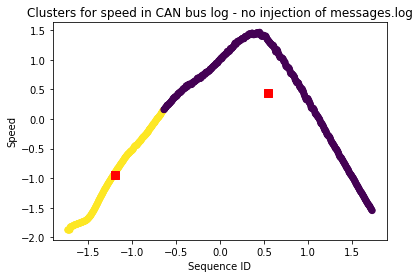

In [ ]:
# Plotting the results for CAN bus log - no injection of messages.log and speed data
plt.scatter(x=speed1['stamp'],y=speed1['value'],c=speed1['KMeans'])
# Printing centroid
plt.scatter(x=np.array(s1[:,0]),y=np.array(s1[:,1]),color='red',s = 60,marker="s")
plt.xlabel("Sequence ID")
plt.ylabel("Speed")
plt.title("Clusters for speed in CAN bus log - no injection of messages.log")
plt.show()

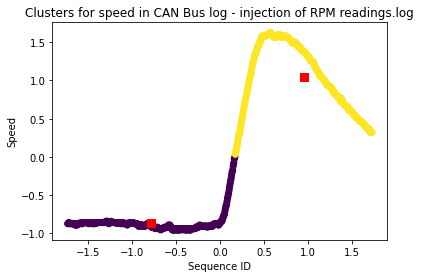

In [ ]:
# Plotting the results for CAN Bus log - injection of RPM readings.log and speed data
plt.scatter(x=speed2['stamp'],y=speed2['value'],c=speed2['KMeans'])
# Printing centroids
plt.scatter(x=np.array(s2[:,0]),y=np.array(s2[:,1]),color='red',s = 60,marker="s")
plt.xlabel("Sequence ID")
plt.ylabel("Speed")
plt.title("Clusters for speed in CAN Bus log - injection of RPM readings.log")
plt.show()

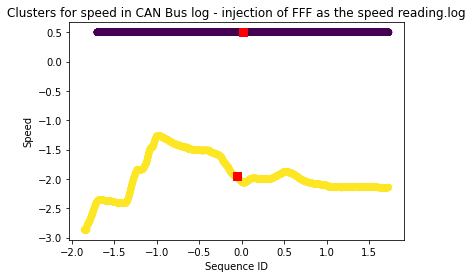

In [ ]:
# Plotting the results for CAN Bus log - injection of FFF as the speed reading.log and speed data
plt.scatter(x=speed3['stamp'],y=speed3['value'],c=speed3['KMeans'])
# Printing centroids
plt.scatter(x=np.array(s3[:,0]),y=np.array(s3[:,1]),color='red',s = 60,marker="s")
plt.xlabel("Sequence ID")
plt.ylabel("Speed")
plt.title("Clusters for speed in CAN Bus log - injection of FFF as the speed reading.log")
plt.show()

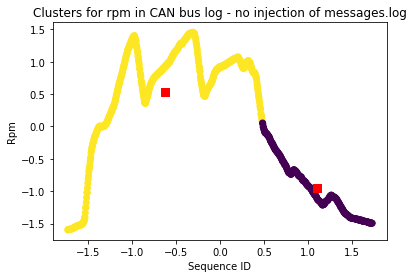

In [ ]:
# Plotting the results for CAN bus log - no injection of messages.log and rpm data
plt.scatter(x=rpm1['stamp'],y=rpm1['value'],c=rpm1['KMeans'])
# Printing centroids
plt.scatter(x=np.array(r1[:,0]),y=np.array(r1[:,1]),color='red',s = 60,marker="s")
plt.xlabel("Sequence ID")
plt.ylabel("Rpm")
plt.title("Clusters for rpm in CAN bus log - no injection of messages.log")
plt.show()

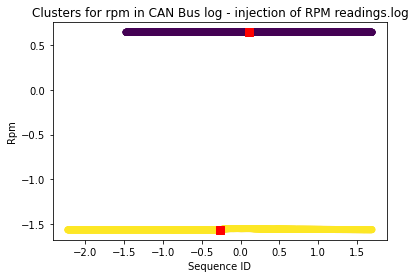

In [ ]:
# Plotting the results for CAN Bus log - injection of RPM readings.log and rpm data
plt.scatter(x=rpm2['stamp'],y=rpm2['value'],c=rpm2['KMeans'])
# Printing centroids
plt.scatter(x=np.array(r2[:,0]),y=np.array(r2[:,1]),color='red',s = 60,marker="s")
plt.xlabel("Sequence ID")
plt.ylabel("Rpm")
plt.title("Clusters for rpm in CAN Bus log - injection of RPM readings.log")
plt.show()

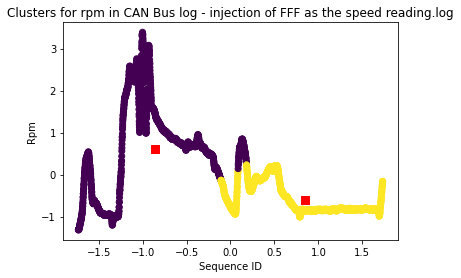

In [ ]:
# Plotting the results for CAN Bus log - injection of FFF as the speed reading.log and rpm data
plt.scatter(x=rpm3['stamp'],y=rpm3['value'],c=rpm3['KMeans'])
# Printing centroids
plt.scatter(x=np.array(r3[:,0]),y=np.array(r3[:,1]),color='red',s = 60,marker="s")
plt.xlabel("Sequence ID")
plt.ylabel("Rpm")
plt.title("Clusters for rpm in CAN Bus log - injection of FFF as the speed reading.log")
plt.show()


### From the above graphs we can observe that we can separate the two clsters with a straight line. So these graphs are linearly seperable. 

# ***Task 3- Isolation Forest Algorithm***

#### You need to fit Isolation Forest separately for the six datasets (1 Speed and 1 RPM data frame for each of the three scenarios).

#### 1.   Use scatter plot to show the fitted isolation forest clusters
#### 2.   Note down data point’s values (for example, RPM = 2700) detected as anomalies by IF.
#### 3.   Compare and discuss the scatter plots of the three scenarios from the speed datasets. Do the same for the RPM datasets.

In [ ]:
# Bilding Isolation Forest Models
IF_s1 = IsolationForest(contamination=0.5)
IF_s2 = IsolationForest(contamination=0.5)
IF_s3 = IsolationForest(contamination=0.5)
IF_r1 = IsolationForest(contamination=0.5)
IF_r2 = IsolationForest(contamination=0.5)
IF_r3 = IsolationForest(contamination=0.5)

In [ ]:
# Fit the model to our dataset
IF_s1.fit(speed1[['value']])
IF_s2.fit(speed2[['value']])
IF_s3.fit(speed3[['value']])
IF_r1.fit(rpm1[['value']])
IF_r2.fit(rpm2[['value']])
IF_r3.fit(rpm3[['value']])

/usr/local/lib/python3.7/dist-packages/sklearn/base.py:451: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  "X does not have valid feature names, but"
/usr/local/lib/python3.7/dist-packages/sklearn/base.py:451: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  "X does not have valid feature names, but"
/usr/local/lib/python3.7/dist-packages/sklearn/base.py:451: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  "X does not have valid feature names, but"
/usr/local/lib/python3.7/dist-packages/sklearn/base.py:451: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  "X does not have valid feature names, but"
/usr/local/lib/python3.7/dist-packages/sklearn/base.py:451: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  "X does not have v

IsolationForest(contamination=0.5)

In [ ]:
# Adding anomaly scores to dataframe
speed1['scores'] = IF_s1.decision_function(speed1[['value']])
speed2['scores'] = IF_s2.decision_function(speed2[['value']])
speed3['scores'] = IF_s3.decision_function(speed3[['value']])
rpm1['scores'] = IF_r1.decision_function(rpm1[['value']])
rpm2['scores'] = IF_r2.decision_function(rpm2[['value']])
rpm3['scores'] = IF_r3.decision_function(rpm3[['value']])

In [ ]:
# Adding anomaly to dataframe
speed1['anomaly'] = IF_s1.predict(speed1[['value']])
speed2['anomaly'] = IF_s2.predict(speed2[['value']])
speed3['anomaly'] = IF_s3.predict(speed3[['value']])
rpm1['anomaly'] = IF_r1.predict(rpm1[['value']])
rpm2['anomaly'] = IF_r2.predict(rpm2[['value']])
rpm3['anomaly'] = IF_r3.predict(rpm3[['value']])

The speed values which are found as outliers are: 
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.4536009687, 0.4536009687, 0.4536009687, 0.5219517995999999, 0.559234071, 0.559234071, 0.5903026305, 0.6586534614, 0.6586534614, 0.7332180042, 0.7642865637, 0.7642865637, 0.8015688351, 0.8015688351, 0.8388511065, 0.8699196659999999, 0.8699196659999999, 0.9382704969, 0.9382704969, 0.9755527682999999, 1.0128350396999999, 1.0128350396999999, 1.0439035991999999, 1.0439035991999999, 1.0811858706, 1.118468142, 1.1495367015, 1.1495367015, 1.2178875323999998, 1.2178875323999998, 1.2551698037999999, 1.2551698037999999, 1.2924520751999997, 1.3235206347, 1.3608029061, 1.3980851774999998, 1.429153737, 1.4664360084, 1.5347868393, 1.5720691107, 1.6404199416, 1.7087707724999999, 1.7771216034, 1.8516861462, 1.9573192485, 1.988387808, 2.0940209103, 2.1623717412, 2.2680048435, 2.3736379458, 2.5165533195, 2.5849041503999994, 2.6905372526999995, 2.7961703549999997, 2.8955897454, 3.0385051191, 3.1441382214, 3.2497713237, 3.3

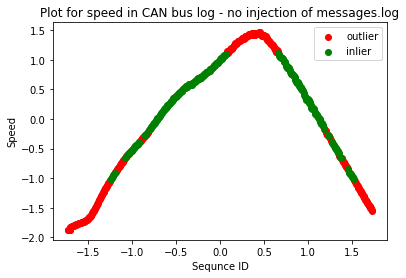

In [ ]:
# Plotting the results for CAN bus log - no injection of messages.log and speed data
plt.scatter(data=speed1.loc[speed1['anomaly']==-1],x="stamp",y="value",color="red")
plt.scatter(data=speed1.loc[speed1['anomaly']==1],x="stamp",y="value",color="green")
plt.legend(["outlier","inlier"])
plt.xlabel("Sequnce ID")
plt.ylabel("Speed")
plt.title("Plot for speed in CAN bus log - no injection of messages.log")
# Printing outliers
print("The speed values which are found as outliers are: ")
outliers1 = list(speed1['SpeedValue'].where(speed1['anomaly'] == -1))
print(outliers1)

The speed values which are found as outliers are: 
[5.381074505399999, 5.381074505399999, 5.381074505399999, 5.381074505399999, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.1325260294, 5.381074505399999, 5.381074505399999, 5.381074505399999, 5.381074505399999, 5.4121430649, 5.449425336299999, 5.4867076077000005, 5.5177761672, 5.555058438599999, 5.555058438599999, 5.592340709999999, 5.6606915409, 5.7290423718, 5.766324643199999, 5.834675474099999, 5.834675474099999, 5.903026305, 5.9713771359, 6.0459416787, 6.0770102382, 6.151574780999999, 6.1826433405, 6.2509941714, 6.3255587142000005, 6.393909545099999, 6.462260376, 6.5306112069,

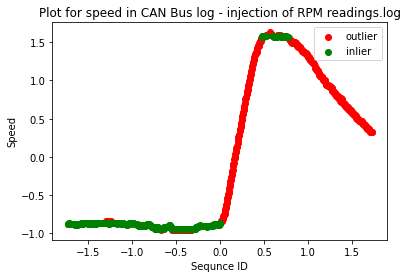

In [ ]:
# Plotting the results for CAN Bus log - injection of RPM readings.log and speed data
plt.scatter(data=speed2.loc[speed2['anomaly']==-1],x="stamp",y="value",color="red")
plt.scatter(data=speed2.loc[speed2['anomaly']==1],x="stamp",y="value",color="green")
plt.legend(["outlier","inlier"])
plt.xlabel("Sequnce ID")
plt.ylabel("Speed")
plt.title("Plot for speed in CAN Bus log - injection of RPM readings.log")
# Printing outliers
print("The speed values which are found as outliers are: ")
outliers2 = list(speed2['SpeedValue'].where(speed2['anomaly'] == -1))
outliers2 = [item for item in outliers2 if not(math.isnan(item)) == True]
print(outliers2)

The speed values which are found as outliers are: 
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.4536009687, 0.5219517995999999, 0.5219517995999999, 0.5219517995999999, 0.6275849018999999, 0.6586534614, 0.6586534614, 0.7332180042, 0.7642865637, 0.7642865637, 0.8015688351, 0.8015688351, 0.8388511065, 0.8699196659999999, 0.8699196659999999, 0.9382704969, 0.9382704969, 1.0128350396999999, 1.0128350396999999, 1.0811858706, 1.0811858706, 1.1495367015, 1.1495367015, 1.2178875323999998, 1.2551698037999999, 1.2924520751999997, 1.3235206347, 1.3608029061, 1.429153737, 1.4664360084, 1.4975045678999999, 1.5720691107, 1.5720691107, 1.6404199416, 1.677702213, 1.7460530439, 1.7771216034, 1.8144038748, 1.8516861462, 1.9200369770999999, 1.9573192485, 2.0256700793999998, 2.0567386388999997, 2.0940209103, 2.1623717412, 2.1996540126, 2.236936284, 2.3052871148999996, 2.3363556744, 2.4109202171999997, 2.4419887766999997, 2.5165533195, 2.547621879, 2.

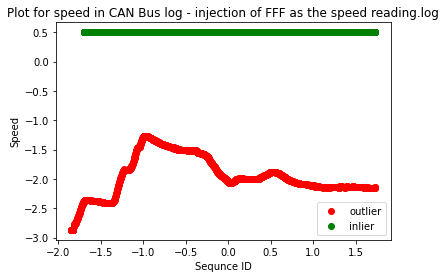

In [ ]:
# Plotting the results for CAN Bus log - injection of FFF as the speed reading.log and speed data
plt.scatter(data=speed3.loc[speed3['anomaly']==-1],x="stamp",y="value",color="red")
plt.scatter(data=speed3.loc[speed3['anomaly']==1],x="stamp",y="value",color="green")
plt.legend(["outlier","inlier"])
plt.xlabel("Sequnce ID")
plt.ylabel("Speed")
plt.title("Plot for speed in CAN Bus log - injection of FFF as the speed reading.log")
# Printing outliers
print("The speed values which are found as outliers are: ")
outliers3 = list(speed3['SpeedValue'].where(speed3['anomaly'] == -1))
outliers3 = [item for item in outliers3 if not(math.isnan(item)) == True]
print(outliers3)

The rpm values which are found as outliers are: 
[636.0, 640.0, 640.0, 638.0, 638.0, 640.0, 640.0, 644.0, 644.0, 644.0, 644.0, 646.0, 646.0, 650.0, 650.0, 650.0, 650.0, 654.0, 654.0, 660.0, 660.0, 662.0, 662.0, 664.0, 664.0, 672.0, 672.0, 672.0, 672.0, 672.0, 672.0, 678.0, 678.0, 680.0, 680.0, 682.0, 682.0, 686.0, 686.0, 688.0, 688.0, 684.0, 684.0, 694.0, 694.0, 696.0, 696.0, 700.0, 758.0, 758.0, 804.0, 854.0, 854.0, 1000.0, 1000.0, 1046.0, 1092.0, 1130.0, 1166.0, 1238.0, 1238.0, 1268.0, 1304.0, 1326.0, 1350.0, 1392.0, 1408.0, 1430.0, 1444.0, 1458.0, 1476.0, 1486.0, 1494.0, 1510.0, 1514.0, 1540.0, 1544.0, 1552.0, 1562.0, 1566.0, 1572.0, 1582.0, 1590.0, 1600.0, 1604.0, 1620.0, 1622.0, 1626.0, 1666.0, 1668.0, 1672.0, 1682.0, 1680.0, 1684.0, 1696.0, 1702.0, 1714.0, 1714.0, 1728.0, 1732.0, 1748.0, 1750.0, 1754.0, 1764.0, 1770.0, 1784.0, 1780.0, 1798.0, 1798.0, 1818.0, 1818.0, 1822.0, 1836.0, 1838.0, 1852.0, 1858.0, 1870.0, 1874.0, 1894.0, 1896.0, 1922.0, 1928.0, 2332.0, 2340.0, 2356.0, 236

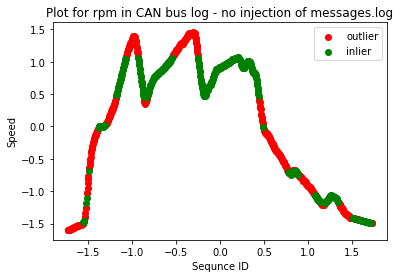

In [ ]:
# Plotting the results for CAN bus log - no injection of messages.log and rpm data
plt.scatter(data=rpm1.loc[rpm1['anomaly']==-1],x="stamp",y="value",color="red")
plt.scatter(data=rpm1.loc[rpm1['anomaly']==1],x="stamp",y="value",color="green")
plt.legend(["outlier","inlier"])
plt.xlabel("Sequnce ID")
plt.ylabel("Speed")
plt.title("Plot for rpm in CAN bus log - no injection of messages.log")
# Printing outliers
print("The rpm values which are found as outliers are: ")
outliers4 = list(rpm1['RPMValue'].where(rpm1['anomaly'] == -1))
outliers4 = [item for item in outliers4 if not(math.isnan(item)) == True]
print(outliers4)

The speed values which are found as outliers are: 
[750.0, 750.0, 750.0, 738.0, 738.0, 736.0, 736.0, 736.0, 736.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 736.0, 736.0, 738.0, 736.0, 736.0, 736.0, 736.0, 738.0, 738.0, 750.0, 750.0, 752.0, 752.0, 750.0, 750.0, 752.0, 752.0, 738.0, 738.0, 750.0, 750.0, 750.0, 750.0, 738.0, 736.0, 736.0, 734.0, 734.0, 738.0, 750.0, 750.0, 752.0, 756.0, 756.0, 728.0, 728.0, 716.0, 716.0, 706.0, 706.0, 706.0, 706.0, 712.0, 716.0, 716.0, 724.0, 724.0, 734.0, 734.0, 734.0, 734.0, 734.0, 734.0, 736.0, 734.0, 734.0, 734.0, 734.0, 738.0, 738.0, 734.0, 732.0, 732.0, 732.0, 732.0, 734.0, 734.0, 732.0, 732.0, 732.0, 734.0, 734.0, 736.0, 736.0, 734.0, 734.0, 738.0, 738.0, 736.0, 736.0, 738.0, 736.0, 736.0, 734.0, 734.0, 736.0, 736.0, 736.0, 738.0, 738.0, 736.0, 736.0, 738.0, 738.0, 738.0, 738.0, 738.0, 738.0, 736.0, 734.0, 734.0, 734.0, 734.0, 732.0, 732.0, 734.0, 734.0, 738.0, 736.0, 736.0, 738.0, 738.0, 738.0, 738.0, 738.0, 738.0, 750

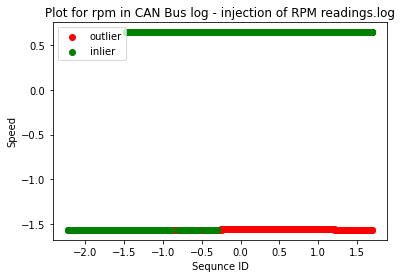

In [ ]:
# Plotting the results for CAN Bus log - injection of RPM readings.log and rpm data
plt.scatter(data=rpm2.loc[rpm2['anomaly']==-1],x="stamp",y="value",color="red")
plt.scatter(data=rpm2.loc[rpm2['anomaly']==1],x="stamp",y="value",color="green")
plt.legend(["outlier","inlier"])
plt.xlabel("Sequnce ID")
plt.ylabel("Speed")
plt.title("Plot for rpm in CAN Bus log - injection of RPM readings.log")
# Printing outliers
print("The speed values which are found as outliers are: ")
outliers5 = list(rpm2['RPMValue'].where(rpm2['anomaly'] == -1))
outliers5 = [item for item in outliers5 if not(math.isnan(item)) == True]
print(outliers5)

The rpm values which are found as outliers are: 
[626.0, 624.0, 624.0, 626.0, 626.0, 626.0, 628.0, 628.0, 634.0, 634.0, 636.0, 636.0, 644.0, 644.0, 648.0, 648.0, 654.0, 654.0, 660.0, 660.0, 664.0, 664.0, 668.0, 668.0, 676.0, 676.0, 680.0, 680.0, 686.0, 686.0, 692.0, 692.0, 694.0, 694.0, 700.0, 716.0, 716.0, 796.0, 814.0, 814.0, 834.0, 834.0, 848.0, 862.0, 862.0, 880.0, 890.0, 890.0, 906.0, 940.0, 956.0, 956.0, 962.0, 970.0, 982.0, 982.0, 988.0, 996.0, 1006.0, 1006.0, 1010.0, 1014.0, 1024.0, 1024.0, 1028.0, 1032.0, 1040.0, 1040.0, 1042.0, 1042.0, 1050.0, 1048.0, 1048.0, 1048.0, 1052.0, 1048.0, 1050.0, 1050.0, 1054.0, 1054.0, 1054.0, 1062.0, 1062.0, 1064.0, 1066.0, 1072.0, 1072.0, 1072.0, 1074.0, 1078.0, 1074.0, 1072.0, 1072.0, 1070.0, 1064.0, 1054.0, 1050.0, 1050.0, 1038.0, 1032.0, 1024.0, 1024.0, 1014.0, 1000.0, 998.0, 998.0, 988.0, 980.0, 972.0, 972.0, 962.0, 952.0, 952.0, 946.0, 916.0, 916.0, 904.0, 888.0, 888.0, 872.0, 872.0, 862.0, 844.0, 844.0, 828.0, 816.0, 816.0, 804.0, 804.0, 7

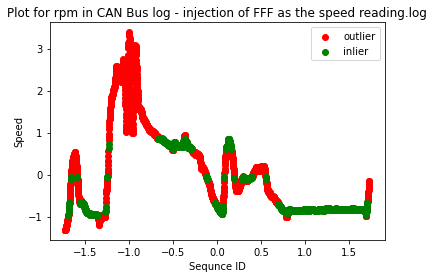

In [ ]:
# Plotting the results for CAN Bus log - injection of FFF as the speed reading.log and rpm data
plt.scatter(data=rpm3.loc[rpm3['anomaly']==-1],x="stamp",y="value",color="red")
plt.scatter(data=rpm3.loc[rpm3['anomaly']==1],x="stamp",y="value",color="green")
plt.legend(["outlier","inlier"])
plt.xlabel("Sequnce ID")
plt.ylabel("Speed")
plt.title("Plot for rpm in CAN Bus log - injection of FFF as the speed reading.log")
# Printing outliers
print("The rpm values which are found as outliers are: ")
outliers6 = list(rpm3['RPMValue'].where(rpm3['anomaly'] == -1))
outliers6 = [item for item in outliers6 if not(math.isnan(item)) == True]
print(outliers6)

### From the above scatter plots we are able to detect the outliers and inliners. In some graphs we can observe that no of outliers are more. The scatter plots are continuous line graphs which are similar to the scatter plots in k means clustering.

# ***Task 4 - Discussion***

#### Write 1-2 paragraphs reflecting on what you have learnt from this assignment. Questions that you may consider are: What were the shortcomings of using unsupervised ML on this problem? What could be done to make the models perform better? What do you suggest doing to solve the problem better?

### *In this assignment I have learned how to build unspervised machine learning algorithms such as k means clustering. I have also learned how to detect outliers with the help of Isolation Forest Algorithm. At first we have prepared the dataset, build the models and produced results. Supervised machine learning algorithms produce more accuracy when compared to unsupervised machine learning algorithms because in supervised machine learning approach we give the ouputs for the model in training phase. In our case both the algorithms produce the correct output.*

# ***Task 5 - Hidden Harkov Models (10 optional points):***

#### Build Hidden Markov Model to predict Attack vs no Attack.

In [ ]:
# speed1 is the data frame for speeds from CAN bus log - no injection of messages.log
# rpm1 is the data frame for rpm from CAN bus log - no injection of messages.log
speed1,rpm1 = getData("/content/CAN bus log - no injection of messages.log")

In [ ]:
# speed2 is the data frame for speeds from CAN Bus log - injection of RPM readings.log
# rpm2 is the data frame for rpm from CAN Bus log - injection of RPM readings.log
speed2,rpm2 = getData("/content/CAN Bus log - injection of RPM readings.log")

In [ ]:
# speed3 is the data frame for speeds from CAN bus log - injection of FFF as the speed reading.log
# rpm3 is the data frame for rpm from CAN bus log - injection of FFF as the speed reading.log
speed3,rpm3 = getData("/content/CAN Bus log - injection of FFF as the speed reading.log")

In [ ]:
# dropping columns
speed1 = speed1.drop(['PID', 'const1', 'change', 'value2'], axis = 1)
rpm1 = rpm1.drop(['PID', 'const1', 'change', 'value2'], axis = 1)
speed2 = speed2.drop(['PID', 'const1', 'change', 'value2'], axis = 1)
rpm2 = rpm2.drop(['PID', 'const1', 'change', 'value2'], axis = 1)
speed3 = speed3.drop(['PID', 'const1', 'change', 'value2'], axis = 1)
rpm3 = rpm3.drop(['PID', 'const1', 'change', 'value2'], axis = 1)


In [ ]:
# function
def HiddenMarkovModel(data):
  hmm = GaussianHMM(n_components=2,random_state=42)
  df = np.array(data["value"]).reshape(-1,1)
  hmm.fit(df)
  result = list(hmm.predict(df))
  print("Actual Value:",list(data['attack']))
  print("Predicted Value:",result)
  print("Accuracy:",accuracy_score(list(data['attack']),result))

In [ ]:
# Results for CAN bus log - no injection of messages.log and speed data
print("HMM results for CAN bus log - no injection of messages.log and speed data")
HiddenMarkovModel(speed1)

HMM results for CAN bus log - no injection of messages.log and speed data
Actual Value: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
# Results for CAN bus log - no injection of messages.log and rpm data
print("HMM results for CAN bus log - no injection of messages.log and rpm data")
HiddenMarkovModel(rpm1)

HMM results for CAN bus log - no injection of messages.log and rpm data
Actual Value: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [ ]:
# Results for CAN bus log - no injection of messages.log and speed data
print("HMM results for CAN bus log - no injection of messages.log and speed data")
HiddenMarkovModel(speed2)

HMM results for CAN bus log - no injection of messages.log and speed data
Actual Value: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
# Results for CAN bus log - no injection of messages.log and rpm data
print("HMM results for CAN bus log - no injection of messages.log and rpm data")
HiddenMarkovModel(rpm2)

HMM results for CAN bus log - no injection of messages.log and rpm data
Actual Value: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1

In [ ]:
# Results for CAN Bus log - injection of FFF as the speed reading.log and speed data
print("HMM results for CAN Bus log - injection of FFF as the speed reading.log and speed data")
HiddenMarkovModel(speed3)

HMM results for CAN Bus log - injection of FFF as the speed reading.log and speed data
Actual Value: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1

In [ ]:
# Results for CAN Bus log - injection of FFF as the speed reading.log and rpm data
print("HMM results for CAN Bus log - injection of FFF as the speed reading.log and rpm data")
HiddenMarkovModel(rpm3)

HMM results for CAN Bus log - injection of FFF as the speed reading.log and rpm data
Actual Value: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 